Average cosine similarity: 0.739 ± 0.196
Min similarity: -0.108
Max similarity: 1.000


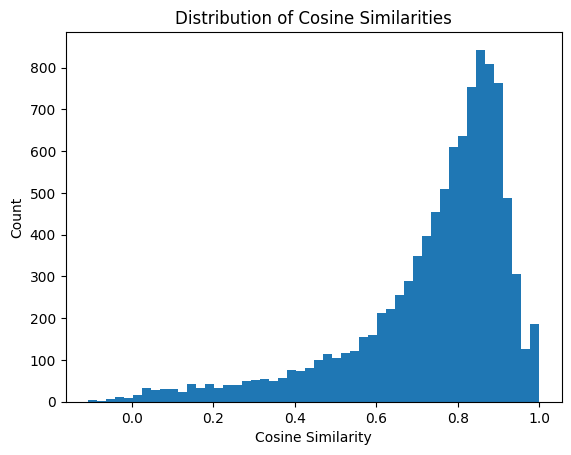

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# Load the data
SAVE_PATH = "/home/ethanliu/VibeCheck/notebooks/disguising/model_responses.csv"
df = pd.read_csv(SAVE_PATH)

# Initialize the sentence transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')  # or any other model you prefer

# Get embeddings for both columns
gpt4o_embeddings = model.encode(df['gpt4o_response'].tolist())
gpt35_embeddings = model.encode(df['gpt35_reprompted'].tolist())
gpt35_reprompted_embeddings = model.encode(df['gpt35_response'].tolist())

# Calculate cosine similarity for each pair
similarities = [cosine_similarity([emb1], [emb2])[0][0] 
               for emb1, emb2 in zip(gpt4o_embeddings, gpt35_embeddings)]

# Calculate statistics
avg_similarity = np.mean(similarities)
std_similarity = np.std(similarities)
min_similarity = np.min(similarities)
max_similarity = np.max(similarities)

print(f"Average cosine similarity: {avg_similarity:.3f} ± {std_similarity:.3f}")
print(f"Min similarity: {min_similarity:.3f}")
print(f"Max similarity: {max_similarity:.3f}")

# Optional: Plot distribution
import matplotlib.pyplot as plt
plt.hist(similarities, bins=50)
plt.title('Distribution of Cosine Similarities')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.show()

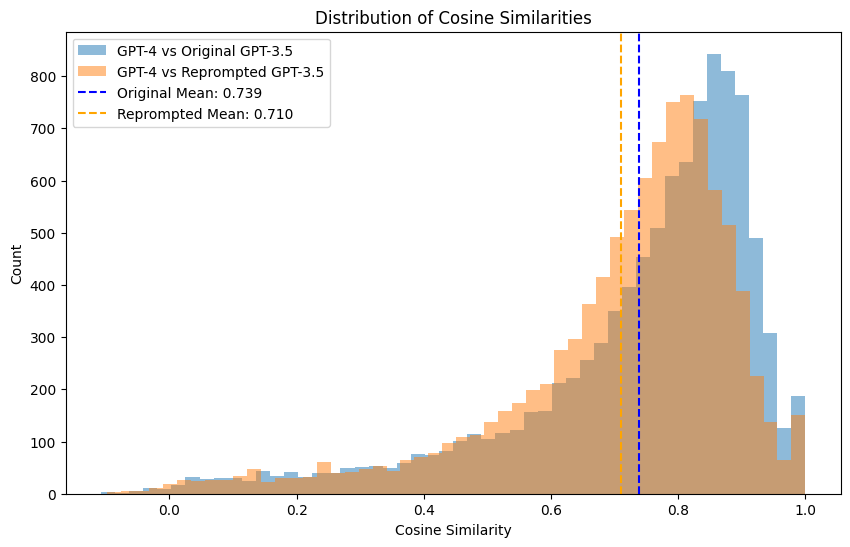

Original GPT-3.5 vs GPT-4:
Average similarity: 0.739 ± 0.196
Min: -0.108, Max: 1.000

Reprompted GPT-3.5 vs GPT-4:
Average similarity: 0.710 ± 0.187
Min: -0.098, Max: 1.000


In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

# Load the data
SAVE_PATH = "/home/ethanliu/VibeCheck/notebooks/disguising/model_responses.csv"
df = pd.read_csv(SAVE_PATH)

# Initialize the sentence transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Get embeddings
gpt4o_embeddings = model.encode(df['gpt4o_response'].tolist())
gpt35_embeddings = model.encode(df['gpt35_response'].tolist())
gpt35_reprompted_embeddings = model.encode(df['gpt35_reprompted'].tolist())

# Calculate similarities
similarities_original = [cosine_similarity([emb1], [emb2])[0][0] 
                       for emb1, emb2 in zip(gpt4o_embeddings, gpt35_embeddings)]
similarities_reprompted = [cosine_similarity([emb1], [emb2])[0][0] 
                         for emb1, emb2 in zip(gpt4o_embeddings, gpt35_reprompted_embeddings)]

# Create single plot with overlaid histograms
plt.figure(figsize=(10, 6))
plt.hist(similarities_original, bins=50, alpha=0.5, label='GPT-4 vs Original GPT-3.5')
plt.hist(similarities_reprompted, bins=50, alpha=0.5, label='GPT-4 vs Reprompted GPT-3.5')

plt.axvline(np.mean(similarities_original), color='blue', linestyle='dashed', 
            label=f'Original Mean: {np.mean(similarities_original):.3f}')
plt.axvline(np.mean(similarities_reprompted), color='orange', linestyle='dashed', 
            label=f'Reprompted Mean: {np.mean(similarities_reprompted):.3f}')

plt.title('Distribution of Cosine Similarities')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.legend()
plt.show()

# Print statistics
print("Original GPT-3.5 vs GPT-4:")
print(f"Average similarity: {np.mean(similarities_original):.3f} ± {np.std(similarities_original):.3f}")
print(f"Min: {np.min(similarities_original):.3f}, Max: {np.max(similarities_original):.3f}\n")

print("Reprompted GPT-3.5 vs GPT-4:")
print(f"Average similarity: {np.mean(similarities_reprompted):.3f} ± {np.std(similarities_reprompted):.3f}")
print(f"Min: {np.min(similarities_reprompted):.3f}, Max: {np.max(similarities_reprompted):.3f}")